# Mann Whitney Statistical Tests
<b> HAVEN model used: 3 hosts at epoch50 </b>

HAVEN vs. LR
HAVEN vs. RF
HAVEN vs. SVM

In [2]:
pip install statannotations

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import sys
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr
import seaborn
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/sanjanag05/.conda/envs/haven/lib/python311.zip',
 '/home/sanjanag05/.conda/envs/haven/lib/python3.11',
 '/home/sanjanag05/.conda/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/sanjanag05/.conda/envs/haven/lib/python3.11/site-packages',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../..']

In [4]:

import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu
from src.utils import visualization_utils

In [5]:
original = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_1e-5_final.csv")
fourhosts_epoch100 = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/4hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
threehosts_epoch100 =  os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
threehosts_epoch50 = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch50_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
fourhosts_epoch50 =  os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/4hosts_epoch50_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
random = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_rf_3hosts_rf_output.csv")
svm_file = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_svm_3hosts_svm_output.csv")
logistic_regression = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_lr_3hosts_lr_output.csv")

og = pd.read_csv(original)
haven = pd.read_csv(threehosts_epoch50)
svm = pd.read_csv(svm_file)
lr = pd.read_csv(logistic_regression)
rf = pd.read_csv(random)


file = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/evaluation/uniref50/20250630/host_multi/host_multi_all_models_evaluation_metrics.csv")
df = pd.read_csv(file)
df.drop(columns="Unnamed: 0", inplace = True)
df = df[df["experiment"] != "3hosts_epoch100"]
df = df.replace({"experiment": {"Logistic Regression": "LR", "SVM": "SVM", "3hosts_epoch50": "HAVEN", "Random Forest": "RF"}})
df["experiment"].unique()

sub_df = df[df["experiment"].isin(["LR", "RF", "SVM", "HAVEN"])]

In [6]:
sub_df["experiment"].unique()

array(['HAVEN', 'RF', 'SVM', 'LR'], dtype=object)

In [7]:
experiments = ['HAVEN','RF', 'SVM', 'LR']
pairs = [#("ProteinBERT", "HAVEN"),
         #("HAVEN", "Transformer-Encoder"),
         ("HAVEN", "RF"), 
         ("HAVEN", "SVM"),
         ("HAVEN", "LR")]

def get_p_value_annotation(p_value):
    if p_value > 5e-2 and p_value <= 1:
        return "ns"
    elif p_value > 1e-2 and p_value <= 5e-2:
        return "*"
    elif p_value > 1e-3 and p_value <= 1e-2:
        return "**"
    elif p_value > 1e-4 and p_value <= 1e-3:
        return "***"
    elif p_value <= 1e-4:
        return "****"
    else:
        return None
    
def plot_boxplot_w_stat_custom_annotation(df, metric, pairs, location, ylim):
    DEFAULT_FIGURE_CONFIG = {
        "figsize": (14, 6),
        "xtick.labelsize": 18,
        "ytick.labelsize": 18
    }
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=df["experiment"].nunique())
    plotting_parameters = {
        'data':    df,
        'x':       'experiment',
        'y':       metric,
        "linewidth": 2,
        #"edgecolor": "black",
        "linecolor": "black",
        "legend": False,
        "hue": "experiment",
#         "boxprops": {"edgecolor": "black"},
#         "whiskerprops": {"color": "black"},
#         "flierprops": {"color": "black"},
#         "fliersize": 7.0,
#         "medianprops": {"linewidth": 2.5},
        'palette': color_palette#sns.color_palette("magma", n_colors=len(experiments)),
        #"notch": True,
        #"fill": False
    }
    
    visualization_utils.pre_plot_config(DEFAULT_FIGURE_CONFIG)
    ax = sns.boxplot(**plotting_parameters, order=experiments)
    sns.stripplot(data=df, x="experiment", y=metric, ax=ax, color="black", size=8, alpha=.7, order=experiments)
    ax.set_xlabel("", size=1, labelpad=5)
    ax.set_ylabel("Macro-AUPRC", size=20)
    plt.draw()
    ax.set_ylim(*ylim)
    
    #plt.tight_layout()
    
    for i, pair in enumerate(pairs):
        model_1_values = df[df["experiment"] == pair[0]][metric].values
        model_2_values = df[df["experiment"] == pair[1]][metric].values
        p_value = mannwhitneyu(model_1_values, model_2_values, alternative="two-sided").pvalue
        formatted_pvalue = f"p={p_value:.2e}"
        print(f"{pair}: p-value={formatted_pvalue}")
        
        x_ticks = [t.get_text()  for t in ax.get_xticklabels()]
        x1 = experiments.index(pair[0])
        x2 = experiments.index(pair[1])
        y1 = max(df[df["experiment"] == pair[0]][metric].max(), 
                 df[df["experiment"] == pair[1]][metric].max()) + (0.06 * (i + 1))
        y2 = y1 + .01
        
        plt.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=2, c="k")
        text = get_p_value_annotation(p_value)
        if text == "ns":
            plt.text((x1 + x2)*.5, y1+0.01, text , ha='center', va='bottom', color="k", size="18")
        else:
            plt.text((x1 + x2)*.5, y1, text, ha='center', va='bottom', color="k", size="18")
    visualization_utils.wrap_ticklabels(ax, axis="x", label_width=10, break_long_words=True)
    plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", f"output/visualization/uniref50/host_multi_all_models_2_boxplot_stat.pdf"), bbox_inches="tight")

('HAVEN', 'RF'): p-value=p=9.52e-02
('HAVEN', 'SVM'): p-value=p=3.17e-02
('HAVEN', 'LR'): p-value=p=4.21e-01


/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


<Figure size 640x480 with 0 Axes>

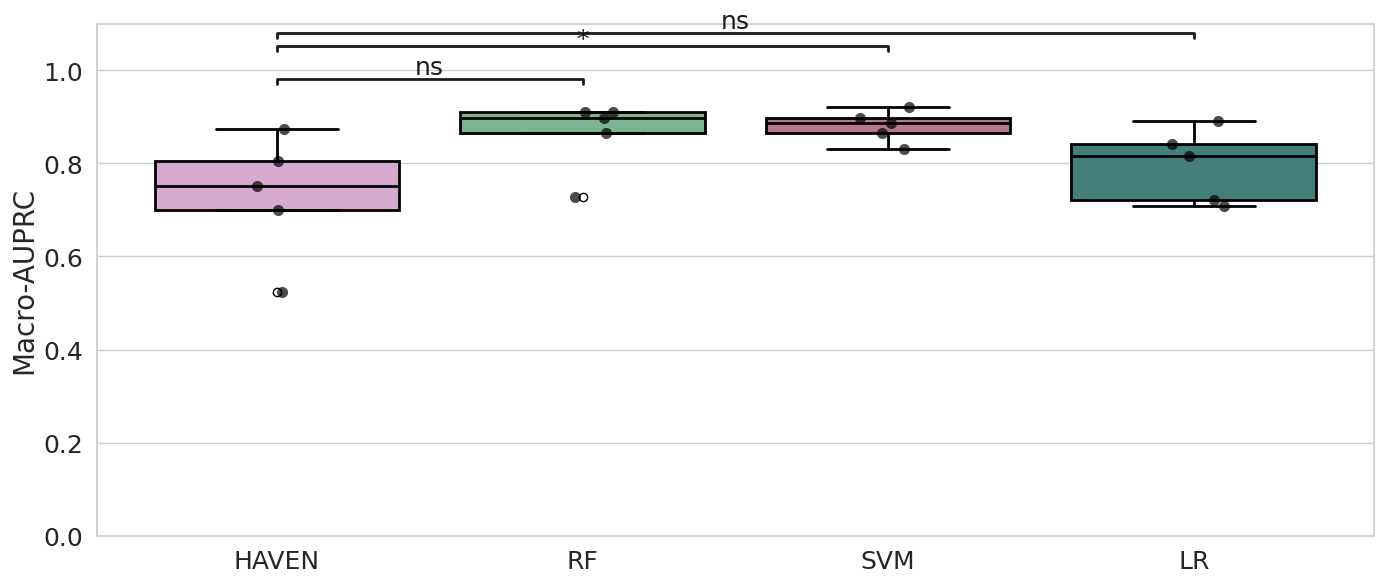

In [8]:
plot_boxplot_w_stat_custom_annotation(sub_df, "auprc", pairs, location="inside", ylim=(0, 1.1))

# P-Value Analysis
('HAVEN', 'RF'): p-value=p=9.52e-02

<b> 0.09 > 0.05, not statistically different </b>

('HAVEN', 'SVM'): p-value=p=3.17e-02

<b> 0.03 < 0.05, statistically different </b>

('HAVEN', 'LR'): p-value=p=4.21e-01

<b> 0.4 > 0.05, not statistically different </b>